In [1]:
import os
import torch
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay,accuracy_score
import numpy as np
import ssl
import pandas as pd
from PIL import Image

## train

In [2]:
data_dir = "images_3"
train_dir = os.path.join(data_dir, "train_images")
val_dir = os.path.join(data_dir, "val_images")
test_dir = os.path.join(data_dir, "test_images")

transform = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

train_dataset = datasets.ImageFolder(train_dir, transform=transform['train'])
val_dataset = datasets.ImageFolder(val_dir, transform=transform['val'])
test_dataset = datasets.ImageFolder(test_dir, transform=transform['test'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(train_dataset.classes)

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
ssl._create_default_https_context = ssl._create_unverified_context

In [5]:
model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
model.classifier[6] = nn.Linear(4096, num_classes)  # thay layer output

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

train_loss_list, val_loss_list = [], []
train_acc_list, val_acc_list = [], []

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\Administrator/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:02<00:00, 108MB/s]  


In [6]:
batch_size = 32
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total
    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")


Epoch [1/20], Train Loss: 0.7320, Train Acc: 0.7791, Val Loss: 0.4766, Val Acc: 0.8821
Epoch [2/20], Train Loss: 0.6372, Train Acc: 0.8270, Val Loss: 0.4852, Val Acc: 0.8801
Epoch [3/20], Train Loss: 0.6150, Train Acc: 0.8333, Val Loss: 0.4708, Val Acc: 0.9031
Epoch [4/20], Train Loss: 0.6002, Train Acc: 0.8375, Val Loss: 0.4471, Val Acc: 0.8981
Epoch [5/20], Train Loss: 0.5951, Train Acc: 0.8398, Val Loss: 0.4478, Val Acc: 0.9001
Epoch [6/20], Train Loss: 0.5878, Train Acc: 0.8404, Val Loss: 0.4235, Val Acc: 0.9031
Epoch [7/20], Train Loss: 0.5826, Train Acc: 0.8439, Val Loss: 0.4353, Val Acc: 0.9001
Epoch [8/20], Train Loss: 0.5792, Train Acc: 0.8445, Val Loss: 0.4189, Val Acc: 0.9071
Epoch [9/20], Train Loss: 0.5718, Train Acc: 0.8460, Val Loss: 0.4216, Val Acc: 0.9141
Epoch [10/20], Train Loss: 0.5719, Train Acc: 0.8447, Val Loss: 0.4208, Val Acc: 0.8991
Epoch [11/20], Train Loss: 0.5681, Train Acc: 0.8443, Val Loss: 0.4288, Val Acc: 0.9061
Epoch [12/20], Train Loss: 0.5655, Train 

In [7]:
torch.save(model.state_dict(), 'alexnet_finetuned.pth')

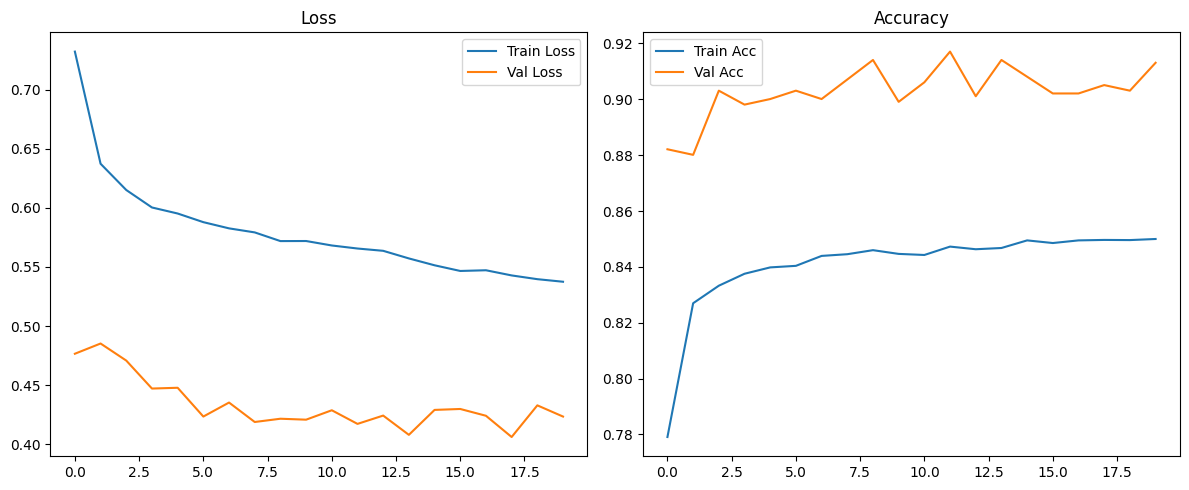

In [8]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_loss_list, label='Train Loss')
plt.plot(val_loss_list, label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(train_acc_list, label='Train Acc')
plt.plot(val_acc_list, label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.tight_layout()
plt.show()

## đánh giá

In [2]:
data_dir = "data/images_3"
test_dir = os.path.join(data_dir, "test_images")

transform = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomVerticalFlip(),
        transforms.ColorJitter(),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
}

test_dataset = datasets.ImageFolder(test_dir, transform=transform['test'])
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(test_dataset.classes)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)
model.classifier[6] = nn.Linear(4096, num_classes)  # thay layer output

model = model.to(device)

model.load_state_dict(torch.load("temp/models/alexnet_finetuned.pth",  map_location=device))

label_map = {'BENIGN': 0, 'Group1' : 1, 'Group2': 2, "Syn": 3 }

In [3]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
test_accuracy = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {test_accuracy * 100:.2f}%")


Test Accuracy: 91.46%


In [5]:
class_names = test_dataset.classes

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       250
           1       0.92      0.92      0.92       250
           2       0.88      0.92      0.90       251
           3       0.93      0.91      0.92       244

    accuracy                           0.91       995
   macro avg       0.92      0.91      0.91       995
weighted avg       0.91      0.91      0.91       995



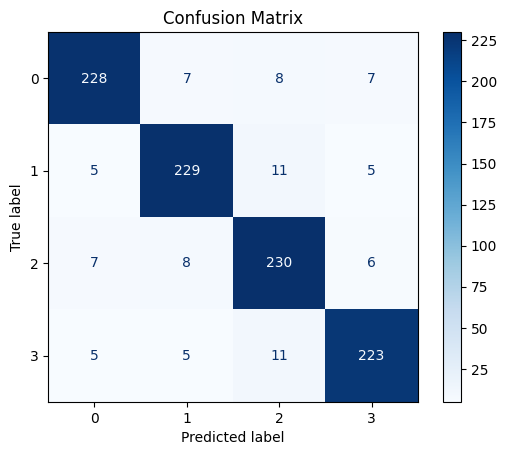

In [6]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

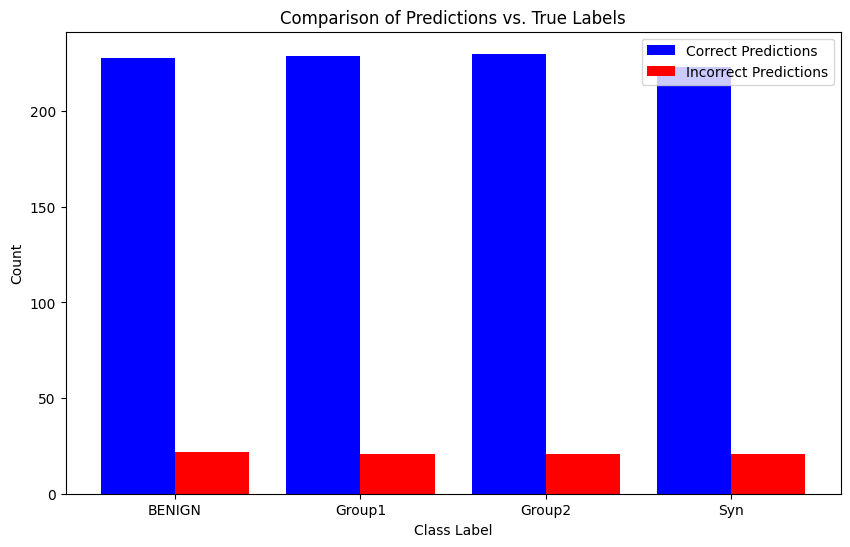

In [ ]:
df = pd.DataFrame({"True Label": all_labels, "Predicted Label": all_preds})
df["Correct"] = (df["True Label"] == df["Predicted Label"])  # True nếu dự đoán đúng

correct_counts = df[df["Correct"]].groupby("True Label").size()
incorrect_counts = df[~df["Correct"]].groupby("True Label").size()

correct_counts = correct_counts.reindex(range(num_classes), fill_value=0)
incorrect_counts = incorrect_counts.reindex(range(num_classes), fill_value=0)

plt.figure(figsize=(10, 6))
bar_width = 0.4
index = np.arange(num_classes)

plt.bar(index, correct_counts, bar_width, label="Correct Predictions", color="blue")
plt.bar(index + bar_width, incorrect_counts, bar_width, label="Incorrect Predictions", color="red")

plt.xlabel("Class Label")
plt.ylabel("Count")
plt.title("Comparison of Predictions vs. True Labels")
plt.xticks(index + bar_width / 2, label_map.keys(), rotation=0)
plt.legend()
plt.show()

In [ ]:
def predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    print(f'Predicted label: {class_names[predicted.item()]}')


def total_predict_image(model, image_path, class_names):
    model.eval()
    image = Image.open(image_path)
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    image = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output, 1)
    return class_names[predicted.item()]

In [ ]:
labels_list = list(label_map.keys())

print(labels_list)
test_data_paths = list(map(lambda x: x, test_dataset.imgs))

# predict_image(model, "data/test/SYN/1.png", list(label_map.keys()))
# predict_image(model, "data/test/haa/rrr.png", list(label_map.keys()))

# predict_image(model, "data/cic_ddos_2019_images/Syn/4343.png", list(label_map.keys()))

for i in range(0, len(labels_list)):
    name_details_dict = {}

    for j in test_data_paths:
        if j[1] == i:
            r = total_predict_image(model, f"{j[0]}", labels_list)
            if r in name_details_dict:
                name_details_dict[r] += 1
            else:
                name_details_dict[r] = 1

    print(f'Label: {labels_list[i]}', name_details_dict)

['BENIGN', 'Group1', 'Group2', 'Syn']
Label: BENIGN {'BENIGN': 228, 'Syn': 7, 'Group2': 8, 'Group1': 7}
Label: Group1 {'BENIGN': 5, 'Group1': 229, 'Group2': 11, 'Syn': 5}
Label: Group2 {'BENIGN': 7, 'Group1': 8, 'Group2': 230, 'Syn': 6}
Label: Syn {'BENIGN': 5, 'Syn': 223, 'Group2': 11, 'Group1': 5}
